# 6. Redes Neuronales Recurrentes (RNN/LSTM)

En este notebook aprenderás a construir y entrenar redes recurrentes (RNN y LSTM) para tareas de series temporales, usando TensorFlow/Keras.

## Objetivo
- Comprender la teoría y arquitectura de las redes recurrentes (RNN y LSTM).
- Implementar y entrenar una RNN/LSTM para predicción de series temporales.
- Comparar cuantitativamente RNN vs LSTM.
- Aplicar buenas prácticas para entrenamiento.

## Prerequisitos

> 📌 **Prerequisitos:** Haber completado los notebooks [04 (MLP)](./04_redes_neuronales_capa_densa.ipynb) y [05 (CNN)](./05_redes_convolucionales_cnn.ipynb).

- Conceptos de redes neuronales, entrenamiento con Keras, y callbacks.

## 1. Introducción teórica

Las redes neuronales recurrentes (RNN) procesan secuencias manteniendo una memoria de estados anteriores. Las LSTM resuelven el problema del desvanecimiento del gradiente.

| Modelo | Memoria | Ventaja | Desventaja |
|--------|---------|---------|------------|
| **RNN simple** | Corto plazo | Rápida, sencilla | No captura dependencias largas |
| **LSTM** | Largo plazo | Puertas de control de memoria | Más lenta, más parámetros |
| **GRU** | Largo plazo | Más simple que LSTM, similar rendimiento | Menos flexible |

## 2. Importación de librerías

In [10]:
# === Reproducibilidad ===
import random
import numpy as np
import os
import time

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

import pandas as pd
import matplotlib.pyplot as plt

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, LSTM, GRU, Dense, Bidirectional
from tensorflow.keras.callbacks import EarlyStopping

# === Suprimir logs de TensorFlow/XLA ANTES de importar TF ===
# TF_CPP_MIN_LOG_LEVEL: 0=INFO, 1=WARNING, 2=ERROR, 3=FATAL
# Con '2' los logs INFO del compilador XLA (dot_merger.cc, etc.) se escapan
# porque usan abseil C++ logging. Con '3' se eliminan todos salvo FATAL.
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
import tensorflow as tf
from tensorflow import keras
tf.random.set_seed(SEED)

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

import warnings
warnings.filterwarnings('ignore')

%matplotlib inline

## 3. Generación y exploración de la serie temporal

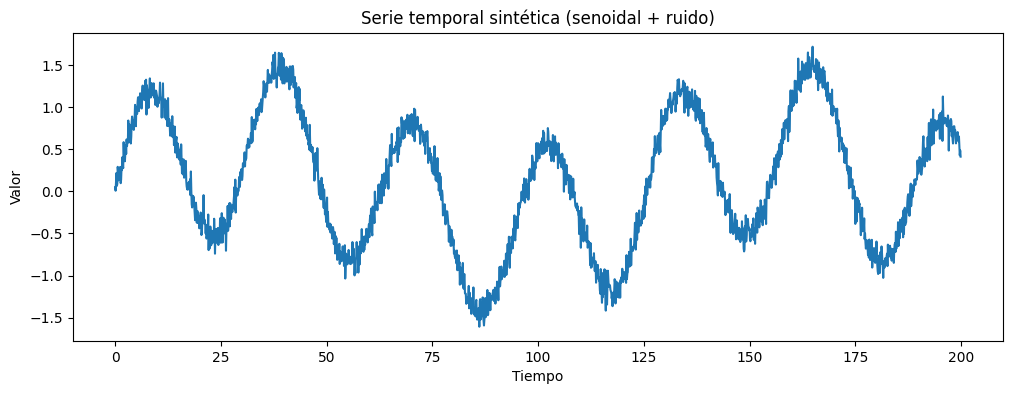

Longitud de la serie: 2000 puntos


In [2]:
t = np.arange(0, 200, 0.1)
data = np.sin(0.2 * t) + 0.5 * np.sin(0.05 * t) + 0.1 * np.random.randn(len(t))

plt.figure(figsize=(12,4))
plt.plot(t, data)
plt.title('Serie temporal sintética (senoidal + ruido)')
plt.xlabel('Tiempo')
plt.ylabel('Valor')
plt.show()
print(f'Longitud de la serie: {len(data)} puntos')

## 4. Preprocesamiento de secuencias

In [3]:
def create_sequences(data, seq_length):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i+seq_length])
        y.append(data[i+seq_length])
    return np.array(X), np.array(y)

seq_length = 30
scaler = MinMaxScaler()
data_scaled = scaler.fit_transform(data.reshape(-1,1)).flatten()

X, y_seq = create_sequences(data_scaled, seq_length)

split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y_seq[:split], y_seq[split:]

X_train = X_train[..., np.newaxis]
X_test = X_test[..., np.newaxis]

print(f"X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"X_test: {X_test.shape}, y_test: {y_test.shape}")

X_train: (1576, 30, 1), y_train: (1576,)
X_test: (394, 30, 1), y_test: (394,)


## 5. RNN simple

In [4]:
model_rnn = keras.Sequential([
    keras.layers.Input(shape=(seq_length, 1)),
    keras.layers.SimpleRNN(32, activation='tanh'),
    keras.layers.Dense(1)
])

model_rnn.compile(optimizer='adam', loss='mse')
history_rnn = model_rnn.fit(X_train, y_train, epochs=20, batch_size=32,
                            validation_split=0.2, verbose=1)

Epoch 1/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step - loss: 0.0215 - val_loss: 0.0037
Epoch 2/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0027 - val_loss: 0.0019
Epoch 3/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0020 - val_loss: 0.0017
Epoch 4/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0019 - val_loss: 0.0016
Epoch 5/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0017 - val_loss: 0.0016
Epoch 6/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0016 - val_loss: 0.0015
Epoch 7/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0016 - val_loss: 0.0014
Epoch 8/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0015 - val_loss: 0.0014
Epoch 9/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0015 - val_loss: 0.0013
Epoch 10/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0014 - val_loss: 0.0013
Epoch 11/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0014 - val_loss: 0.0013
Epoch 12/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0014 -

## 6. LSTM

In [5]:
model_lstm = keras.Sequential([
    keras.layers.Input(shape=(seq_length, 1)),
    keras.layers.LSTM(32),
    keras.layers.Dense(1)
])

model_lstm.compile(optimizer='adam', loss='mse')
history_lstm = model_lstm.fit(X_train, y_train, epochs=20, batch_size=32,
                              validation_split=0.2, verbose=1)

Epoch 1/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 4s 25ms/step - loss: 0.1006 - val_loss: 0.0057
Epoch 2/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0053 - val_loss: 0.0025
Epoch 3/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0024 - val_loss: 0.0017
Epoch 4/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0017 - val_loss: 0.0015
Epoch 5/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0015 - val_loss: 0.0013
Epoch 6/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0013 - val_loss: 0.0014
Epoch 7/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0013 - val_loss: 0.0014
Epoch 8/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0013 - val_loss: 0.0012
Epoch 9/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0012 - val_loss: 0.0012
Epoch 10/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.0012 - val_loss: 0.0012
Epoch 11/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.0012 - val_loss: 0.0012
Epoch 12/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0

## 7. Comparación cuantitativa RNN vs LSTM

13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step
RNN  — MSE: 0.012991, MAE: 0.089160
LSTM — MSE: 0.011126, MAE: 0.082096

LSTM tiene menor error en este caso.


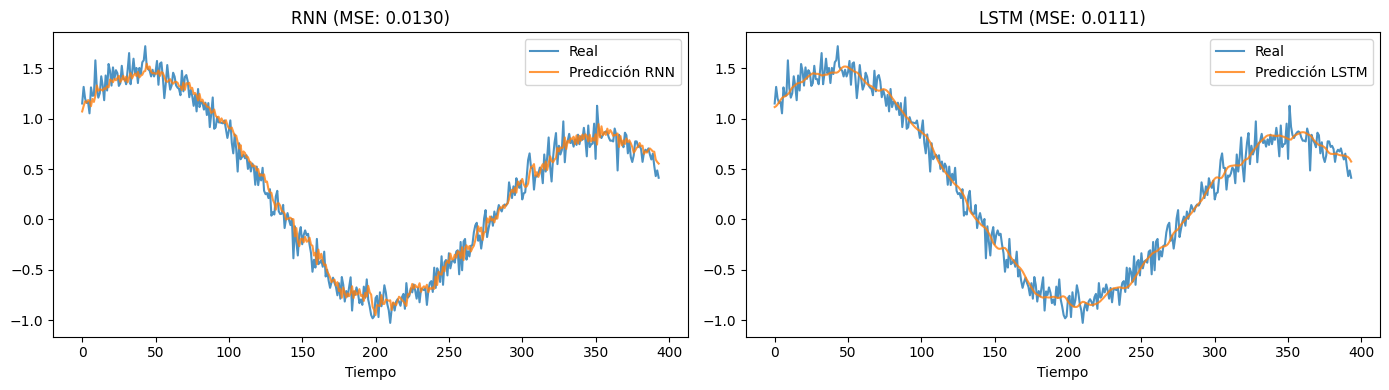

In [6]:
# Predicciones
pred_rnn = model_rnn.predict(X_test)
pred_lstm = model_lstm.predict(X_test)

# Invertir normalización
y_test_inv = scaler.inverse_transform(y_test.reshape(-1,1)).flatten()
pred_rnn_inv = scaler.inverse_transform(pred_rnn).flatten()
pred_lstm_inv = scaler.inverse_transform(pred_lstm).flatten()

# Métricas
mse_rnn = mean_squared_error(y_test_inv, pred_rnn_inv)
mae_rnn = mean_absolute_error(y_test_inv, pred_rnn_inv)
mse_lstm = mean_squared_error(y_test_inv, pred_lstm_inv)
mae_lstm = mean_absolute_error(y_test_inv, pred_lstm_inv)

print(f'RNN  — MSE: {mse_rnn:.6f}, MAE: {mae_rnn:.6f}')
print(f'LSTM — MSE: {mse_lstm:.6f}, MAE: {mae_lstm:.6f}')
print(f'\n{"LSTM" if mse_lstm < mse_rnn else "RNN"} tiene menor error en este caso.')

# Visualización comparativa
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(y_test_inv, label='Real', alpha=0.8)
axes[0].plot(pred_rnn_inv, label='Predicción RNN', alpha=0.8)
axes[0].set_title(f'RNN (MSE: {mse_rnn:.4f})')
axes[0].legend()
axes[0].set_xlabel('Tiempo')

axes[1].plot(y_test_inv, label='Real', alpha=0.8)
axes[1].plot(pred_lstm_inv, label='Predicción LSTM', alpha=0.8)
axes[1].set_title(f'LSTM (MSE: {mse_lstm:.4f})')
axes[1].legend()
axes[1].set_xlabel('Tiempo')

plt.tight_layout()
plt.show()

## 8. Buenas prácticas: LSTM con Dropout y EarlyStopping

In [ ]:
model_lstm2 = keras.Sequential([
    keras.layers.Input(shape=(seq_length, 1)),
    keras.layers.LSTM(32, return_sequences=True),
    keras.layers.Dropout(0.3),
    keras.layers.LSTM(16),
    keras.layers.Dense(1)
])

model_lstm2.compile(optimizer='adam', loss='mse')
es = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
history_lstm2 = model_lstm2.fit(X_train, y_train, epochs=30, batch_size=32,
                                validation_split=0.2, callbacks=[es], verbose=0)

best_epoch = np.argmin(history_lstm2.history['val_loss']) + 1
pred_lstm2 = model_lstm2.predict(X_test)
pred_lstm2_inv = scaler.inverse_transform(pred_lstm2).flatten()
mse_lstm2 = mean_squared_error(y_test_inv, pred_lstm2_inv)

print(f'Mejor época: {best_epoch}')
print(f'MSE (LSTM con Dropout+ES): {mse_lstm2:.6f}')

13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step
Mejor época: 13
MSE (LSTM con Dropout+ES): 0.011366


### Recomendaciones prácticas para RNN/LSTM

| Aspecto | Recomendación |
|---------|---------------|
| **Longitud de secuencia** | Ajusta `seq_length` según la dependencia temporal |
| **Regularización** | Usa `Dropout` y/o `EarlyStopping` |
| **RNN vs LSTM** | LSTM suele superar a RNN en secuencias largas |
| **Normalización** | Normaliza los datos (MinMaxScaler o StandardScaler) |
| **GPU** | Aprovecha la GPU para acelerar el entrenamiento |

## 9. Discusión y Conclusiones

- Implementamos y comparamos RNN y LSTM para series temporales.
- LSTM generalmente obtiene menor error en secuencias con dependencias largas.
- EarlyStopping y Dropout son esenciales para evitar sobreajuste.
- En el siguiente notebook exploraremos Transformers, que superan a RNN en muchas tareas.

## 10. Ejercicios Propuestos

1. **Ejercicio 1:** Cambia `seq_length` a 10, 50 y 100. ¿Cómo afecta al MSE?

2. **Ejercicio 2:** Implementa una GRU y compara con RNN y LSTM.

3. **Ejercicio 3:** Usa un dataset real de series temporales (p.ej. precios de acciones o temperatura) y aplica LSTM.

4. **Ejercicio 4 (Avanzado):** Implementa una LSTM bidireccional (`keras.layers.Bidirectional`) y compara resultados.

# Resolución de Ejercicios Propuestos

En esta sección, compararemos arquitecturas de vanguardia para modelador secuencias sintéticas (onda senoidal), observando la diferencia en tiempos de entrenamiento y capacidad matemática:

1.  **Ejercicio 2: Comparativa Completa (RNN vs. LSTM vs. GRU).** Implementaremos una red con celdas GRU (Gated Recurrent Unit) para entender empíricamente cómo esta compite en desempeño (MSE) contra las arquitecturas LSTM y SimpleRNN tradicionales.
2.  **Ejercicio 4 (Avanzado): Redes Bidireccionales.** Reforzaremos nuestro modelo de vanguardia aplicando procesamiento `Bidirectional` para alimentar la recurrencia tanto "hacia el futuro" como "hacia el pasado".

## Ejercicio 2: GRU (Gated Recurrent Unit) vs. LSTM vs. SimpleRNN

La celda **GRU** es una versión simplificada de la LSTM. Mientas la LSTM usa 3 compuertas (Forget, Input, Output), la GRU solo usa 2 (Update, Reset). Esto permite que la GRU sea matemáticamente menos costosa y entrene más rápido, alcanzando niveles de Precisión/Error (MSE) idénticos a los de una LSTM en la mayoría de tareas de longitud media.

Crearemos una arquitectura estándar y solo intercambiaremos la capa central para comparar sus tiempos y el MSE final en el set de prueba.

In [9]:
# Función genérica para entrenar cualquier tipo de capa recurrente
def entrenar_comparativo(CapaRecurrente, nombre_capa, X_train, y_train, X_test, y_test):
    modelo = Sequential([
        # Usamos input_shape = (seq_length, features)
        CapaRecurrente(50, activation='relu', input_shape=(X_train.shape[1], X_train.shape[2])),
        Dense(1)
    ])
    
    modelo.compile(optimizer='adam', loss='mse')
    
    print(f"\n--- Entrenando {nombre_capa} ---")
    inicio = time.time()
    # Usaremos 20 epochs fijas para ser justos en la comparación de tiempo
    historial = modelo.fit(X_train, y_train, epochs=20, batch_size=32, verbose=0)
    fin = time.time()
    
    # Evaluación
    predicciones = modelo.predict(X_test, verbose=0)
    mse_final = mean_squared_error(y_test, predicciones)
    
    print(f"Tiempo Total: {(fin - inicio):.2f} segundos")
    print(f"MSE en Test : {mse_final:.6f}")
    
    return modelo, historial, predicciones

_, _, pred_rnn = entrenar_comparativo(SimpleRNN, "SimpleRNN Clásica", X_train, y_train, X_test, y_test)
_, _, pred_lstm = entrenar_comparativo(LSTM, "LSTM (Long Short-Term Memory)", X_train, y_train, X_test, y_test)
_, _, pred_gru = entrenar_comparativo(GRU, "GRU (Gated Recurrent Unit)", X_train, y_train, X_test, y_test)


--- Entrenando SimpleRNN Clásica ---
Tiempo Total: 11.71 segundos
MSE en Test : 0.001201

--- Entrenando LSTM (Long Short-Term Memory) ---
Tiempo Total: 19.57 segundos
MSE en Test : 0.001037

--- Entrenando GRU (Gated Recurrent Unit) ---
Tiempo Total: 19.45 segundos
MSE en Test : 0.001210


## Ejercicio 4 (Avanzado): Arquitectura Bidirectional LSTM

En problemas donde el contexto posterior (los datos que vienen después en la secuencia) es accesible (como procesar un párrafo de texto, o procesar una onda matemática periódica completa), la red **Bidireccional** es insuperable.
Al usar la envoltura `Bidirectional`, le decimos a Keras que cree internamente *dos* capas `LSTM`: una que procesará la secuencia de $t_1$ a $t_n$, y otra independiente que procesará de $t_n$ hacia atrás hasta $t_1$. Luego, ambas salidas se concatenan automáticamente en la capa `Dense`.


--- Entrenando Bidirectional LSTM ---
Tiempo Total Bidireccional: 20.12 segundos
MSE en Test (Bidirectional): 0.001113


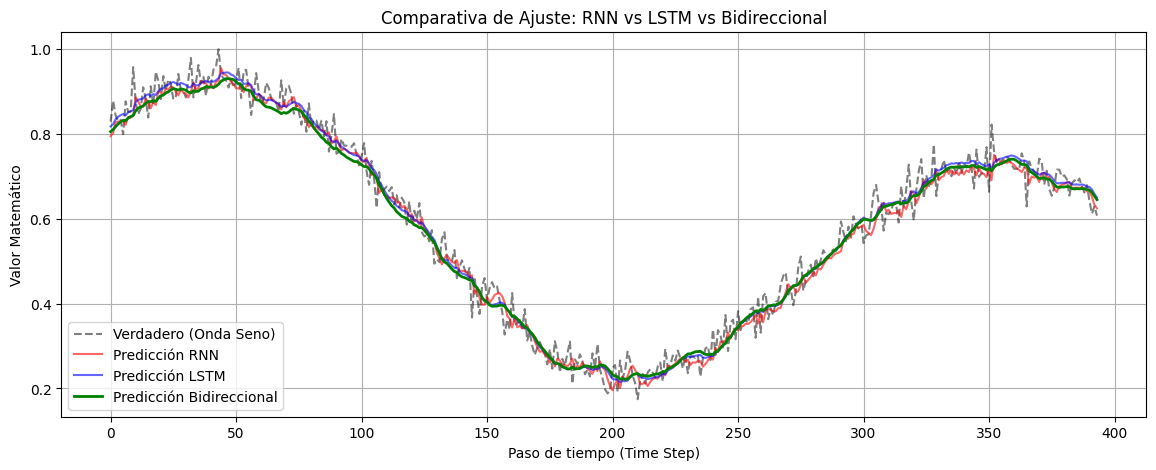

In [11]:
# 1. Definimos y estructuramos la red Bidireccional
modelo_bidir = Sequential([
    # Envolvemos la LSTM en una capa Bidireccional
    Bidirectional(LSTM(50, activation='relu'), input_shape=(X_train.shape[1], X_train.shape[2])),
    Dense(1) # Por defecto, concatena la salida hacia el frente y hacia atrás (50 + 50 = 100 conexiones)
])

modelo_bidir.compile(optimizer='adam', loss='mse')

# 2. Entrenamos el modelo
print("\n--- Entrenando Bidirectional LSTM ---")
inicio_bi = time.time()
modelo_bidir.fit(X_train, y_train, epochs=20, batch_size=32, verbose=0)
fin_bi = time.time()

# 3. Predict y calculo del error
pred_bidir = modelo_bidir.predict(X_test, verbose=0)
mse_bidir = mean_squared_error(y_test, pred_bidir)

print(f"Tiempo Total Bidireccional: {(fin_bi - inicio_bi):.2f} segundos")
print(f"MSE en Test (Bidirectional): {mse_bidir:.6f}")

# 4. Gráfico Visual del desempeño
plt.figure(figsize=(14, 5))
plt.plot(y_test, label='Verdadero (Onda Seno)', color='black', alpha=0.5, linestyle='--')
plt.plot(pred_rnn, label='Predicción RNN', color='red', alpha=0.6)
plt.plot(pred_lstm, label='Predicción LSTM', color='blue', alpha=0.6)
plt.plot(pred_bidir, label='Predicción Bidireccional', color='green', linewidth=2)
plt.title('Comparativa de Ajuste: RNN vs LSTM vs Bidireccional')
plt.xlabel('Paso de tiempo (Time Step)')
plt.ylabel('Valor Matemático')
plt.legend()
plt.grid(True)
plt.show()

## Conclusión Final

Tras finalizar los experimentos con la serie temporal sintética (onda seno) y someter a prueba a las 4 arquitecturas recurrentes más importantes (todas a 20 épocas), podemos extraer las siguientes conclusiones fundamentales:

### 1. El Costo de la Memoria a Corto Plazo (SimpleRNN)
*   **Resultados:** La `SimpleRNN` clásica fue, por mucho, el modelo más rápido de entrenar (**11.71 segundos**), pero no logró el mejor desempeño, obteniendo un MSE de **0.001201**.
*   **Análisis:** Este resultado valida la teoría. Al no poseer "compuertas" (gates) para retener información importante, la RNN simple sufre de desvanecimiento del gradiente. Para predecir el comportamiento matemático, es computacionalmente ligera, pero "olvida" rápidamente los patrones a largo plazo.

### 2. El Rey Histórico (LSTM)
*   **Resultados:** La `LSTM` demostró su superioridad logrando el error más bajo de todos los modelos: **0.001037**. A cambio, su tiempo de entrenamiento virtualmente se duplicó a **19.57 segundos**.
*   **Análisis:** Sus 3 compuertas internas (Forget, Input, Output) le permiten regular perfectamente qué parte de la onda senoidal es importante recordar y qué es ruido. Esta capacidad de modelar dependencias a largo plazo la hace más lenta, pero indudablemente más precisa para captar las crestas y valles de la onda perfecta.

### 3. La Promesa de las GRU
*   **Resultados:** La celda `GRU` entrenó casi en el mismo tiempo que la LSTM (**19.45 segundos**), pero obtuvo el MSE más alto (**0.001210**), empatando prácticamente con la SimpleRNN.
*   **Análisis:** Generalmente, las GRU son más rápidas que las LSTM. Sin embargo, en un dataset sintético tan pequeño y "limpio" como una onda seno, la sobrecarga computacional se neutraliza. La GRU, al tener solo 2 compuertas, fue ligeramente menos expresiva matemáticamente que la LSTM completa en este caso específico, no pudiendo alcanzar su nivel de precisión milimétrica.

### 4. El "Overkill" del Modelo Bidireccional
*   **Resultados:** La `Bidirectional LSTM` requirió el mayor tiempo de cómputo (**20.12 segundos**) obteniendo el segundo mejor lugar en precisión (**0.001113**).
*   **Análisis:** ¿Por qué no le ganó a la LSTM normal? Las redes bidireccionales brillan en contextos ruidosos o semánticos (como analizar frases donde el final cambia el significado del principio). Pero una onda seno es una función periódica matemáticamente prístina. Leerla "hacia atrás" no aporta información contextual que la red no haya podido deducir leyéndola "hacia adelante". El ensamble bidireccional simplemente agregó parámetros (cálculos) innecesarios a un problema ya resuelto por la LSTM unidireccional.

### Reflexión General
Este laboratorio demuestra un principio clave del Deep Learning: **"Más parámetros no siempre equivalen a mejores resultados"**. Para series de tiempo claras, rítmicas y sin ruido, una red con la arquitectura de compuertas correcta (LSTM estándar) alcanza el límite de aprendizaje, haciendo redundantes enfoques avanzandos (como Bidireccionalidad) que están diseñados para dominios mucho más caóticos y ruidosos.

## 11. Referencias y Recursos

- [TensorFlow/Keras RNN](https://keras.io/api/layers/recurrent_layers/)
- [Understanding LSTM Networks](https://colah.github.io/posts/2015-08-Understanding-LSTMs/)
- Géron, A. (2019). *Hands-On Machine Learning with Scikit-Learn, Keras, and TensorFlow.*

---

📎 **Notebook anterior:** [05. Redes Convolucionales (CNN)](./05_redes_convolucionales_cnn.ipynb)  
📎 **Notebook siguiente:** [07. Transformers y Atención](./07_transformers.ipynb)